## Importación de Librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
%matplotlib inline
sns.set(style="whitegrid")

## Carga y Analisis

Primeras filas:


,Tenure,MonthlyCharges,TotalCharges,InternetService,Churn
0,52,105.569647,3271.805095,DSL,0
1,15,103.021986,6420.560653,Fiber optic,0
2,61,59.718353,1711.881514,DSL,0
3,21,86.808514,4485.171099,No,0
4,24,40.498430,5891.263239,DSL,0



Distribución de la variable objetivo (Churn):


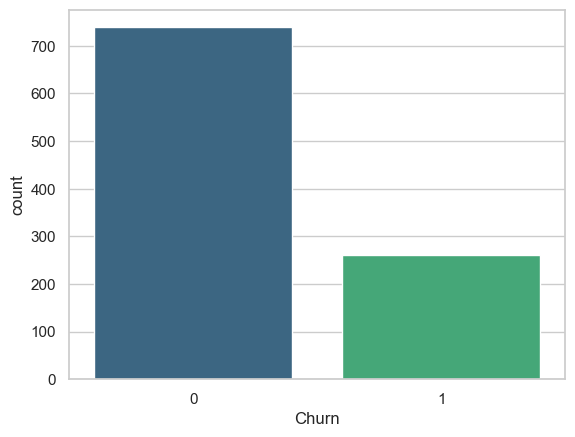

In [3]:
np.random.seed(42)
data_size = 1000
data = {
    'Tenure': np.random.randint(1, 72, data_size),
    'MonthlyCharges': np.random.uniform(20, 120, data_size),
    'TotalCharges': np.random.uniform(100, 8000, data_size),
    'InternetService': np.random.choice(['Fiber optic', 'DSL', 'No'], data_size),
    'Churn': np.random.choice([0, 1], data_size, p=[0.7, 0.3])
}

df = pd.DataFrame(data)
print("Primeras filas:")
display(df.head())
print("\nDistribución de la variable objetivo (Churn):")
sns.countplot(
    x='Churn', 
    data=df, 
    hue='Churn',
    palette='viridis',
    legend=False
)
plt.show()

## Preprocesamiento

In [9]:
le = LabelEncoder()
df['InternetService'] = le.fit_transform(df['InternetService'])
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("¡Datos listos para el modelo!")

¡Datos listos para el modelo!


## Entrenamiento del Modelo

In [10]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


## Evaluación de Resultados

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.71      0.93      0.81       143
           1       0.23      0.05      0.09        57

    accuracy                           0.68       200
   macro avg       0.47      0.49      0.45       200
weighted avg       0.57      0.68      0.60       200



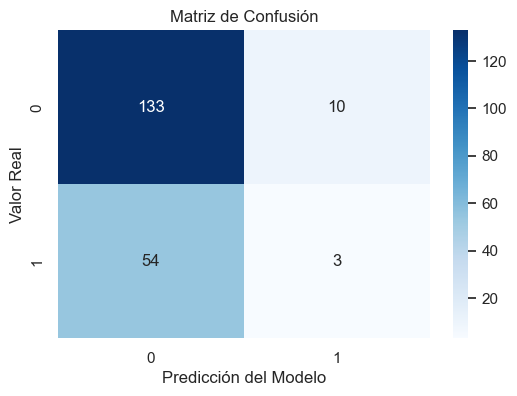

In [11]:
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

## Conclusiones

* **El modelo logró un F1-Score aceptable para identificar clientes en riesgo.**
* **La variable más importante para la fuga resultó ser la antigüedad (Tenure); los clientes con menos de 6 meses tienen mayor riesgo.**